# Analyses of syllables

In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import glob

# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.spatial import distance_matrix, distance
from scipy.stats import zscore
from scipy import stats

# Get my functions
functions_path =  prefix + 'representation_learning_variability/Functions/'
os.chdir(functions_path)
# from data_processing import save_and_log
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//2_fit_models/'
os.chdir(functions_path)
from preprocessing_functions import idxs_from_files
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial/4_analyses/5_clustering_analyses/'
os.chdir(functions_path)
# from clustering_functions import calculate_entropy
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette
from one.api import ONE
one = ONE(mode='remote')

In [3]:
data_path = prefix + 'representation_learning_variability/paper-individuality/1_segmentation/'
# states_file = pd.read_parquet(data_path+'states_trial_type_5k_5_09-24-2025')
# states_file = pd.read_parquet(data_path+'states_trial_type_09-29-2025')
# states_file = pd.read_parquet(data_path+'states_trial_type_09-29-2025')
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = str(data_path + 'all_sequences_09-29-2025')
# all_sequences = pd.read_parquet(filename)

# states_file = pd.read_parquet(data_path+'states_trial_type_wheel_02-16-2026')
# states_file = pd.read_parquet(data_path+'states_trial_type_09-29-2025')
states_file = pd.read_parquet(data_path+'training_states_08_05_2026')


In [ ]:
## Training data
identifiable_mapping = {}
counter = 0
for wheel in [0, 1, 2]:
    for lick in [0, 1]:
        for whisk in [0, 1]:
            key = f"{whisk}{lick}{wheel}"
            identifiable_mapping[key] = float(counter)
            counter += 1
identifiable_mapping["nan"] = np.nan

# Polar plots

In [7]:
def draw_ring(prob_list, r_inner, r_outer, start_angle, colors, lw=1.5):
    for p, c in zip(prob_list, colors):
        theta = 2*np.pi*p
        ax.bar(start_angle + theta/2, r_outer-r_inner, width=theta, bottom=r_inner, color=c, edgecolor='white', linewidth=lw)
        start_angle += theta
    return start_angle

def plot_polar(session, digits):
    
    P_wheel = digits["wheel"].value_counts(normalize=True).sort_index()
    P_paw_given_wheel = digits.groupby("wheel")["paw"].value_counts(normalize=True).unstack().fillna(0).sort_index()
    P_whisk_given = digits.groupby(["wheel","paw"])["whisk"].value_counts(normalize=True).unstack().fillna(0).sort_index()
    P_lick_given = digits.groupby(["wheel","paw","whisk"])["lick"].value_counts(normalize=True).unstack().fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'polar'})
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_axis_off()
    radii = [(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.0)]
    # Plot wheel
    start = 0
    # colors_wheel = plt.cm.Blues(np.linspace(0,1,len(P_wheel)))
    # for p,c in zip(P_wheel.values, colors_wheel):
    for wheel_val, p_wheel in P_wheel.items():
        theta = 2*np.pi*p_wheel
        ax.bar(start + theta/2, radii[0][1]-radii[0][0], width=theta, bottom=radii[0][0], color=plt.cm.Blues(0.3+0.6*wheel_val), edgecolor='white', linewidth=2)
        start += theta

    # Plot paw given wheel
    start = 0
    paw_palette = sns.color_palette('Set2', 8)
    for wheel_val, p_wheel in P_wheel.items():
        for paw_val, p in P_paw_given_wheel.loc[wheel_val].items():
            theta = 2*np.pi*p_wheel*p
            ax.bar(start + theta/2, radii[1][1]-radii[1][0], width=theta, bottom=radii[1][0], color=paw_palette[paw_val], edgecolor='white') # plt.cm.Blues(0.3+0.6*paw_val)
            start += theta

    # Plot whisk given
    start = 0
    for wheel_val, p_wheel in P_wheel.items():
        for paw_val, p_paw in P_paw_given_wheel.loc[wheel_val].items():
            base = p_wheel*p_paw
            if (wheel_val, paw_val) not in P_whisk_given.index:
                continue
            sub = P_whisk_given.loc[(wheel_val, paw_val)]
            for whisk_val, p in sub.items():
                theta = 2*np.pi*base*p
                ax.bar(start + theta/2, radii[2][1]-radii[2][0], width=theta, bottom=radii[2][0], color=plt.cm.Oranges(0.3+0.6*whisk_val), edgecolor='white')
                start += theta

    start = 0
    for wheel_val, p_wheel in P_wheel.items():
        for paw_val, p_paw in P_paw_given_wheel.loc[wheel_val].items():
            if (wheel_val, paw_val) not in P_whisk_given.index:
                continue
            for whisk_val, p_whisk in P_whisk_given.loc[(wheel_val,paw_val)].items():
                base = p_wheel*p_paw*p_whisk
                if (wheel_val, paw_val, whisk_val) not in P_lick_given.index:
                    continue
                sub = P_lick_given.loc[(wheel_val, paw_val, whisk_val)]
                for lick_val, p in sub.items():
                    theta = 2*np.pi*base*p
                    ax.bar(start + theta/2, radii[3][1]-radii[3][0], width=theta, bottom=radii[3][0], color=plt.cm.Greens(0.3+0.6*lick_val), edgecolor='white', linewidth=0.5)
                    start += theta

    plt.title(session, va='bottom')
    plt.show()

In [8]:
def plot_single_polar(ax, digits, title):

    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # =========================
    # ---- PROBABILITIES ------
    # =========================

    # -------- Wheel --------
    wheel_counts = digits.groupby(["trial_id", "wheel"]).size()
    wheel_table = wheel_counts.unstack(fill_value=0)
    wheel_within_trial = wheel_table.div(wheel_table.sum(axis=1), axis=0)
    P_wheel = wheel_within_trial.mean()
    P_wheel = P_wheel / P_wheel.sum()

    # -------- Paw | Wheel --------
    paw_counts = digits.groupby(["trial_id", "wheel", "paw"]).size()
    paw_table = paw_counts.unstack(fill_value=0)
    paw_within_trial = paw_table.div(paw_table.sum(axis=1), axis=0)

    P_paw_given = (
        paw_within_trial
        .groupby("wheel")
        .mean()
        .sort_index()
    )
    P_paw_given = P_paw_given.div(P_paw_given.sum(axis=1), axis=0)

    # -------- Whisk | Wheel, Paw --------
    whisk_counts = digits.groupby(
        ["trial_id", "wheel", "paw", "whisk"]
    ).size()

    whisk_table = whisk_counts.unstack(fill_value=0)
    whisk_within_trial = whisk_table.div(
        whisk_table.sum(axis=1), axis=0
    )

    P_whisk_given = (
        whisk_within_trial
        .groupby(["wheel", "paw"])
        .mean()
        .sort_index()
    )
    P_whisk_given = P_whisk_given.div(
        P_whisk_given.sum(axis=1), axis=0
    )

    # -------- Lick | Wheel, Paw, Whisk --------
    lick_counts = digits.groupby(
        ["trial_id", "wheel", "paw", "whisk", "lick"]
    ).size()

    lick_table = lick_counts.unstack(fill_value=0)
    lick_within_trial = lick_table.div(
        lick_table.sum(axis=1), axis=0
    )

    P_lick_given = (
        lick_within_trial
        .groupby(["wheel", "paw", "whisk"])
        .mean()
        .sort_index()
    )
    P_lick_given = P_lick_given.div(
        P_lick_given.sum(axis=1), axis=0
    )

    # =========================
    # ---- POLAR PLOT ---------
    # =========================

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    # 4 rings now
    radii = [(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.0)]

    paw_palette = sns.color_palette('Set2', 8)

    # --------------------
    # Wheel (inner ring)
    # --------------------
    start = 0
    for wheel_val, p_wheel in P_wheel.items():

        theta = 2*np.pi*p_wheel
        if theta <= 0 or np.isnan(theta):
            continue

        ax.bar(start + theta/2,
               radii[0][1]-radii[0][0],
               width=theta,
               bottom=radii[0][0],
               color=plt.cm.Blues(0.3+0.6*wheel_val),
               edgecolor='white',
               linewidth=2)

        start += theta

    # --------------------
    # Paw | Wheel
    # --------------------
    start = 0
    for wheel_val, p_wheel in P_wheel.items():

        if wheel_val not in P_paw_given.index:
            continue

        for paw_val, p_paw in P_paw_given.loc[wheel_val].items():

            theta = 2*np.pi*p_wheel*p_paw
            if theta <= 0 or np.isnan(theta):
                continue

            ax.bar(start + theta/2,
                   radii[1][1]-radii[1][0],
                   width=theta,
                   bottom=radii[1][0],
                   color=paw_palette[int(paw_val)],
                   edgecolor='white')

            start += theta

    # --------------------
    # Whisk | Wheel, Paw
    # --------------------
    start = 0
    for wheel_val, p_wheel in P_wheel.items():

        if wheel_val not in P_paw_given.index:
            continue

        for paw_val, p_paw in P_paw_given.loc[wheel_val].items():

            base_wp = p_wheel * p_paw

            if (wheel_val, paw_val) not in P_whisk_given.index:
                continue

            for whisk_val, p_whisk in P_whisk_given.loc[(wheel_val, paw_val)].items():

                theta = 2*np.pi*base_wp*p_whisk
                if theta <= 0 or np.isnan(theta):
                    continue

                ax.bar(start + theta/2,
                       radii[2][1]-radii[2][0],
                       width=theta,
                       bottom=radii[2][0],
                       color=plt.cm.Oranges(0.3+0.6*whisk_val),
                       edgecolor='white')

                start += theta

    # --------------------
    # Lick | Wheel, Paw, Whisk
    # --------------------
    start = 0
    for wheel_val, p_wheel in P_wheel.items():

        if wheel_val not in P_paw_given.index:
            continue

        for paw_val, p_paw in P_paw_given.loc[wheel_val].items():

            base_wp = p_wheel * p_paw

            if (wheel_val, paw_val) not in P_whisk_given.index:
                continue

            for whisk_val, p_whisk in P_whisk_given.loc[(wheel_val, paw_val)].items():

                base = base_wp * p_whisk

                if (wheel_val, paw_val, whisk_val) not in P_lick_given.index:
                    continue

                for lick_val, p_lick in P_lick_given.loc[
                    (wheel_val, paw_val, whisk_val)
                ].items():

                    theta = 2*np.pi*base*p_lick
                    if theta <= 0 or np.isnan(theta):
                        continue

                    ax.bar(start + theta/2,
                           radii[3][1]-radii[3][0],
                           width=theta,
                           bottom=radii[3][0],
                           color=plt.cm.Greens(0.3+0.6*lick_val),
                           edgecolor='white',
                           linewidth=0.5)

                    start += theta

    ax.set_title(title, va='bottom')


In [9]:
def plot_single_polar_3(ax, digits, title):

    # Count per trial
    paw_counts = digits.groupby(["trial_id", "paw"]).size()
    # Convert to table so missing paws become 0
    paw_table = (paw_counts.unstack(fill_value=0))
    # Normalize within trial
    paw_within_trial = paw_table.div(paw_table.sum(axis=1), axis=0)
    # Mean across ALL trials
    P_paw = paw_within_trial.mean()
    # Renormalize to sum to 1 (for polar safety)
    P_paw = P_paw / P_paw.sum()

    whisk_counts = digits.groupby(["trial_id", "paw", "whisk"]).size()
    # Make full 3D table
    whisk_table = (whisk_counts.unstack(fill_value=0))
    # Normalize within trial + paw
    whisk_within_trial = (whisk_table.div(whisk_table.sum(axis=1), axis=0))
    # Now average across ALL trials for each paw
    P_whisk_given = (whisk_within_trial.groupby("paw").mean().sort_index())
    # Ensure rows sum to 1
    P_whisk_given = P_whisk_given.div(P_whisk_given.sum(axis=1), axis=0)

    lick_counts = digits.groupby(["trial_id", "paw", "whisk", "lick"]).size()
    lick_table = (lick_counts .unstack(fill_value=0))
    # Normalize within trial + paw + whisk
    lick_within_trial = (lick_table.div(lick_table.sum(axis=1), axis=0))
    # Average across ALL trials
    P_lick_given = (
        lick_within_trial
        .groupby(["paw", "whisk"])
        .mean()
        .sort_index())
    # Ensure conditional normalization
    P_lick_given = (P_lick_given.div(P_lick_given.sum(axis=1), axis=0))

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    # 3 rings now
    radii = [(0.25,0.5),(0.5,0.75),(0.75,1.0)]

    paw_palette = sns.color_palette('Set2', 8)

    # --------------------
    # Paw (inner ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        theta = 2*np.pi*p_paw
        if theta == 0 or np.isnan(theta):
            continue

        ax.bar(start + theta/2,
               radii[0][1]-radii[0][0],
               width=theta,
               bottom=radii[0][0],
               color=paw_palette[int(paw_val)],
               edgecolor='white',
               linewidth=2)

        start += theta

    # --------------------
    # Whisk | Paw (middle ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        if paw_val not in P_whisk_given.index:
            continue

        sub = P_whisk_given.loc[paw_val]

        for whisk_val, p in sub.items():

            theta = 2*np.pi*p_paw*p
            if theta == 0 or np.isnan(theta):
                continue
            ax.bar(start + theta/2,
                   radii[1][1]-radii[1][0],
                   width=theta,
                   bottom=radii[1][0],
                   color=plt.cm.Oranges(0.3+0.6*whisk_val),
                   edgecolor='white')

            start += theta

    # -------------------
    # Lick | Paw, Whisk (outer ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        if paw_val not in P_whisk_given.index:
            continue

        for whisk_val, p_whisk in P_whisk_given.loc[paw_val].items():

            base = p_paw * p_whisk

            if (paw_val, whisk_val) not in P_lick_given.index:
                continue

            sub = P_lick_given.loc[(paw_val, whisk_val)]

            for lick_val, p in sub.items():

                theta = 2*np.pi*base*p
                if theta == 0 or np.isnan(theta):
                    continue
                ax.bar(start + theta/2,
                       radii[2][1]-radii[2][0],
                       width=theta,
                       bottom=radii[2][0],
                       color=plt.cm.Greens(0.3+0.6*lick_val),
                       edgecolor='white',
                       linewidth=0.5)

                start += theta

    ax.set_title(title, va='bottom')


In [ ]:
mice = states_file[['mouse_name', 'session', 'broader_label']].drop_duplicates().sort_values(by='mouse_name')
sessions = mice['session'].unique()

for s, session in enumerate(sessions):

    states = states_file.loc[states_file['session']==session].reset_index()
    mouse_name = list(states['mouse_name'])[0]
    identifiable_states = states["identifiable_states"].dropna()
    digits = identifiable_states.str.extract(r'(\d)(\d)(\d)').astype(int)
    digits.columns = ["whisk", "lick", "wheel"]

    # digits = identifiable_states.str.extract(r'(\d)(\d)(\d)').astype(int)
    # digits.columns = ["paw", "whisk", "lick"]
    states['whisk'] = digits['whisk']
    states['lick'] = digits['lick']
    states['wheel'] = digits['wheel']

    fig, axes = plt.subplots(1, 4,figsize=(16,4),
        subplot_kw={'projection': 'polar'})
    
    title = str(mouse_name+session)
    print(title)
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        use_data = states.loc[states['broader_label']==epoch]
        ax = axes[e]
        plot_single_polar(ax, use_data, epoch)
    plt.show()

KeyboardInterrupt: 

## Plots

In [8]:

def wheel_over_wavelet_clusters(init, inter, empirical_data, session_trials, save_path=None, color_states):
    plot_min = -10
    plot_max = 10
    frame_rate = 60
    fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[20, 5])
    plt.rc('font', size=12)
    plot_var = 'Lick count'
    plot_var = 'whisker_me'
    
    # Get the data for plotting
    plot_data = empirical_data.loc[empirical_data['Bin']>=init, plot_var].reset_index()[plot_var]
    if plot_var != "Lick count":
        # Apply z-scoring to the data
        plot_data = (plot_data - plot_data.mean()) / plot_data.std()
    else:
        # Keep original data for Lick count
        plot_data = plot_data
    color_data = np.concatenate([empirical_data.loc[empirical_data['Bin']>=init, color_states]])
    
    # Plot the main trace - matplotlib automatically handles NaN by creating gaps
    ax.plot(plot_data, color='black')
    
    # Create a masked array for imshow to handle NaN values
    color_data_masked = np.ma.masked_invalid(color_data)  # Mask NaN values
    
    ax.imshow(color_data_masked[None,:],
                extent=(0, len(color_data), -10, 10),
                aspect="auto",
                cmap='Set2',
                alpha=0.6)

    ax.vlines(np.array(session_trials['goCueTrigger_times'] -init)*frame_rate, plot_min, plot_max, label='Stim On', 
                color='Black', linewidth=2)
    ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==1, 'feedback_times'] * frame_rate)-init*frame_rate, 
                plot_min, plot_max, label='Correct', color='Green', linewidth=2, linestyle='dashed')
    ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==-1, 'feedback_times'] * frame_rate)-init*frame_rate, 
                plot_min, plot_max, label='Incorrect', color='Red', linewidth=2, linestyle='dashed')
    ax.vlines(np.array(session_trials['firstMovement_times'] * frame_rate)-init*frame_rate, plot_min, plot_max, label='First movement', color='cyan')
    ax.vlines(np.array(session_trials['intervals_0'] * frame_rate)-init*frame_rate, plot_min, plot_max, label='Trial end', color='Grey', linewidth=2)
    ax.vlines(np.array((session_trials['goCueTrigger_times'] - session_trials['quiescencePeriod']) * frame_rate)-init*frame_rate, 
                plot_min, plot_max, label='Quiescence start', color='Pink', linewidth=2)
    
    ax.set_xlim([0, inter])
    ax.set_ylim([-10, 10])

    ax.set_ylabel(color_states)
    ax.set_xlabel("Time (s)")

    ax.set_xticks(np.arange(0, inter, inter/5), np.round(np.arange(0, inter/frame_rate, (inter/frame_rate)/5)))
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim([-10, 10])
    ax.set_ylim([-5, 10])

    plt.tight_layout()    
    # os.makedirs(os.path.dirname(save_path), exist_ok=True)
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()  # Close the figure to free memory

SyntaxError: non-default argument follows default argument (2250981183.py, line 1)

In [10]:
states.keys()

Index(['Bin', 'Lick count', 'avg_wheel_vel', 'whisker_me', 'l_paw_x',
       'l_paw_y', 'r_paw_x', 'r_paw_y', 'whisker_me_states',
       'Lick count_states', 'wheel_states', 'identifiable_states',
       'most_likely_states', 'correct', 'choice', 'contrast', 'block',
       'reaction', 'response', 'elongation', 'wsls', 'trial_id',
       'goCueTrigger_times', 'label', 'mouse_name', 'session',
       'broader_label'],
      dtype='object')

In [26]:
mouse_name

0         PL016
1         PL016
2         PL016
3         PL016
4         PL016
          ...  
163966    PL016
163967    PL016
163968    PL016
163969    PL016
163970    PL016
Name: mouse_name, Length: 155775, dtype: object

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['whisk'] = digits['whisk']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['lick'] = digits['lick']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

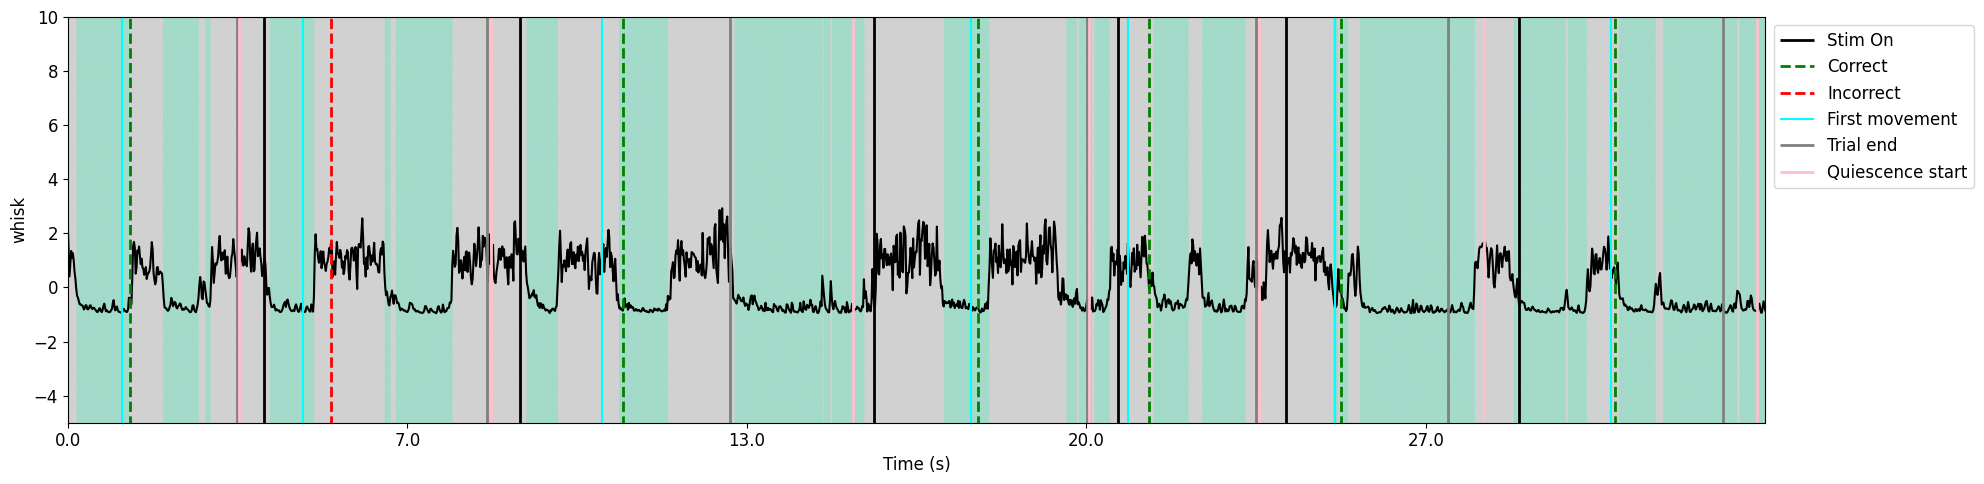

1c2f2c3f-5949-405f-bef6-64ab47506949


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['whisk'] = digits['whisk']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['lick'] = digits['lick']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

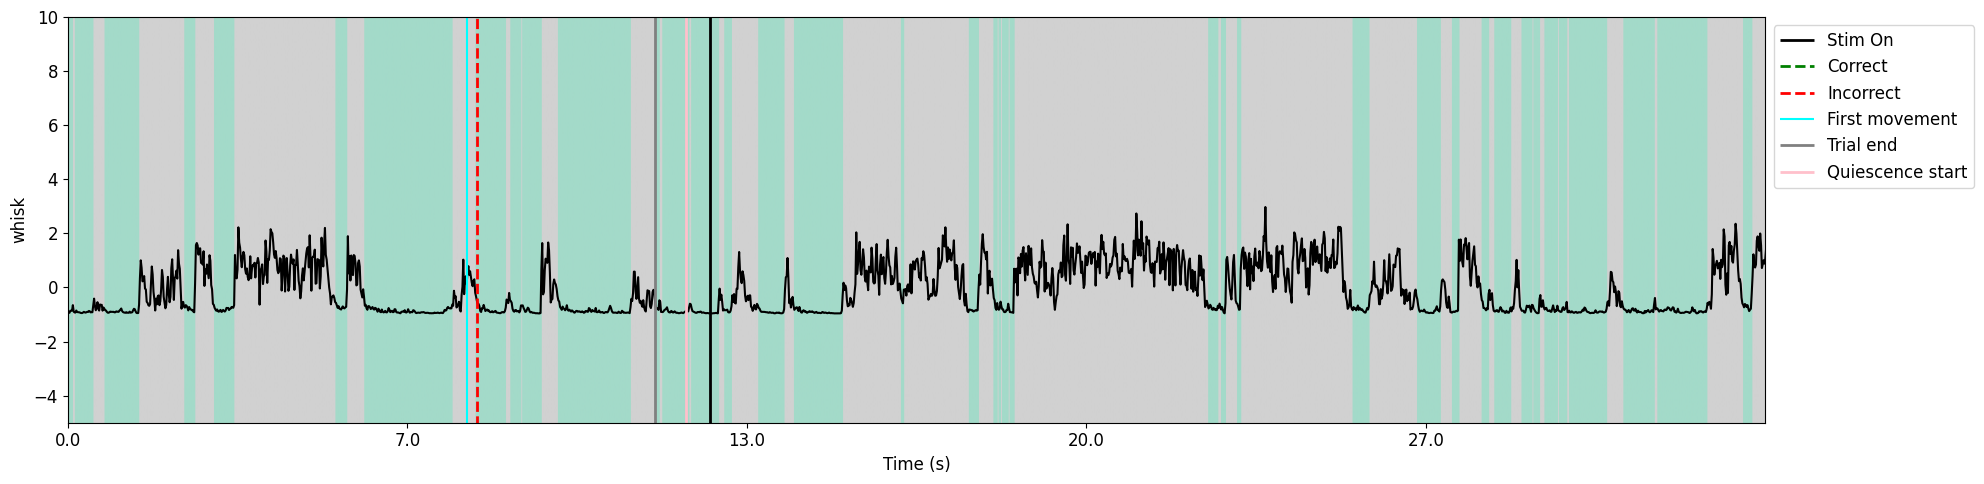

1d3a8b71-b200-4279-8341-532232a9c3e7


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['whisk'] = digits['whisk']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['lick'] = digits['lick']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

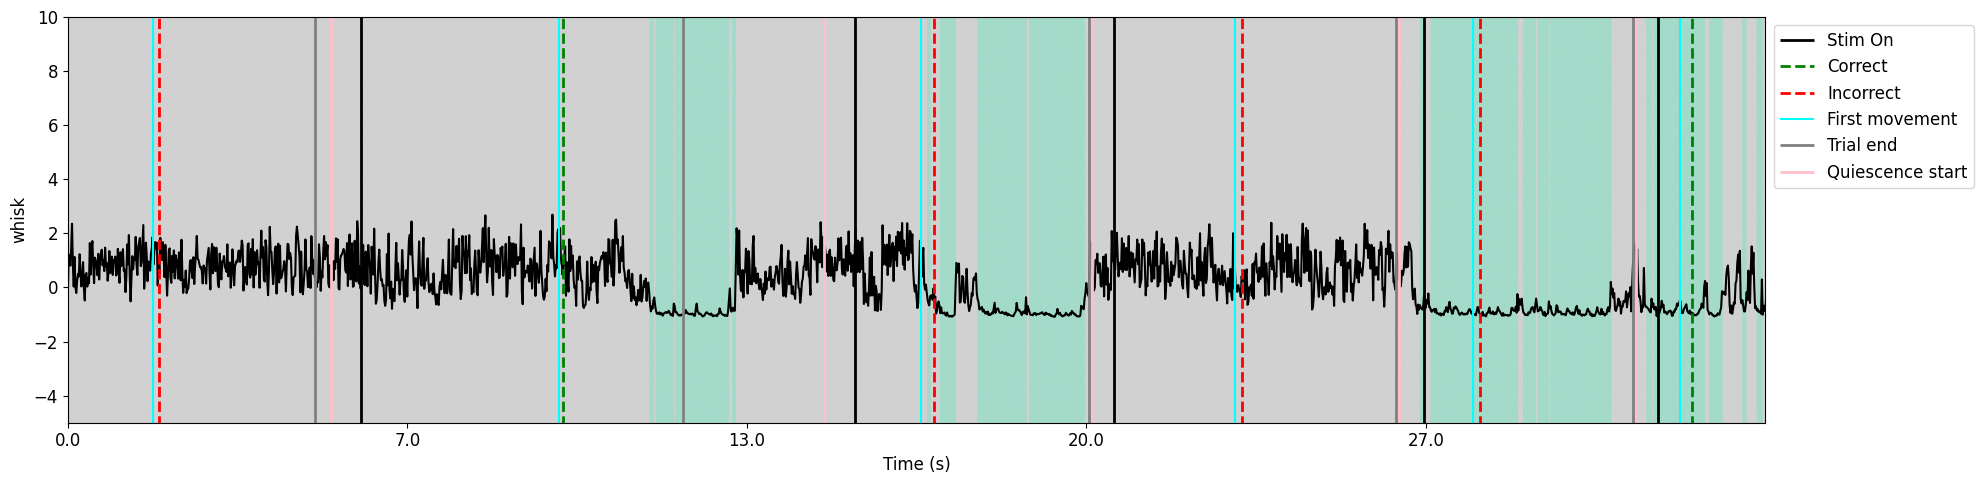

ee589f73-1ab0-4f90-b917-8609aa4e937c


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['whisk'] = digits['whisk']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states['lick'] = digits['lick']
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_38210/518322484.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

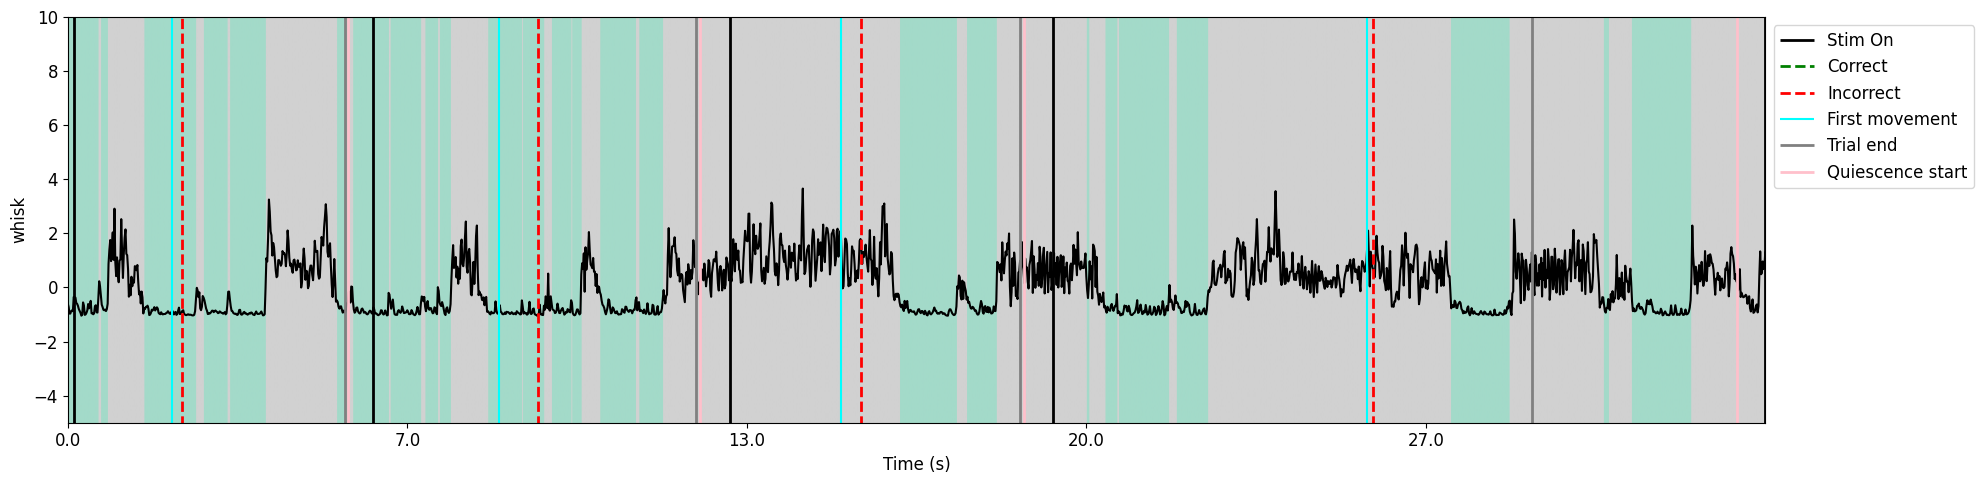

1299a56e-dee1-4fa9-9fb9-6bc14c51f439


In [28]:
mice = states_file[['mouse_name', 'session', 'broader_label']].drop_duplicates().sort_values(by='mouse_name')
sessions = mice['session'].unique()
data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/design_matrices/training/'
save_states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/training_states/'

sessions = states_file['session'].dropna().unique()
for s, session in enumerate(sessions):
    # session = '3537d970-f515-4786-853f-23de525e110f'
    mouse_name = list(states_file.loc[states_file['session']==session, 'mouse_name'])[0]
    states = states_file.loc[states_file['session']==session]
    fit_id = str(mouse_name+session)
    trials_file = data_path + "session_trials_" + str(session) + '_'  + mouse_name
    session_trials = pd.read_parquet(trials_file).reset_index()  #, engine='pyarrow'
    matrix_file = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(matrix_file, engine='pyarrow').reset_index() 

    identifiable_states = states["identifiable_states"] #.dropna()
    digits = identifiable_states.str.extract(r'(\d)(\d)(\d)').astype(int)
    digits.columns = ["whisk", "lick" , "wheel"] #
    states['whisk'] = digits['whisk']
    states['lick'] = digits['lick']
    states['wheel'] = digits['wheel']
    states['epoch'] = pd.factorize(states['broader_label'])[0]

    # Plot raw trace over states       
    init = 2000
    inter = 2000
    var_name = 'whisk'
    save_filename = save_states_path + "states_file_" + str(session) + '_'  + mouse_name
    wheel_over_wavelet_clusters(init, inter, states, session_trials, save_filename, 'whisk')
    print(session)
    # wheel_over_wavelet_clusters(init, inter, states, session_trials, 'paw')

In [86]:
from scipy.signal import butter, filtfilt

def lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)


def low_pass(signal, cutoff, sf):    
    not_nan = signal[np.where(~np.isnan(signal))]
    low_pass = lowpass_filter(not_nan, cutoff, fs=sf, order=4)
    signal[np.where(~np.isnan(signal))] = low_pass
    return signal

In [ ]:
filtered = low_pass(np.array(design_matrix['avg_whisker_me']), cutoff=20, sf=60)

KeyError: 'whisk'

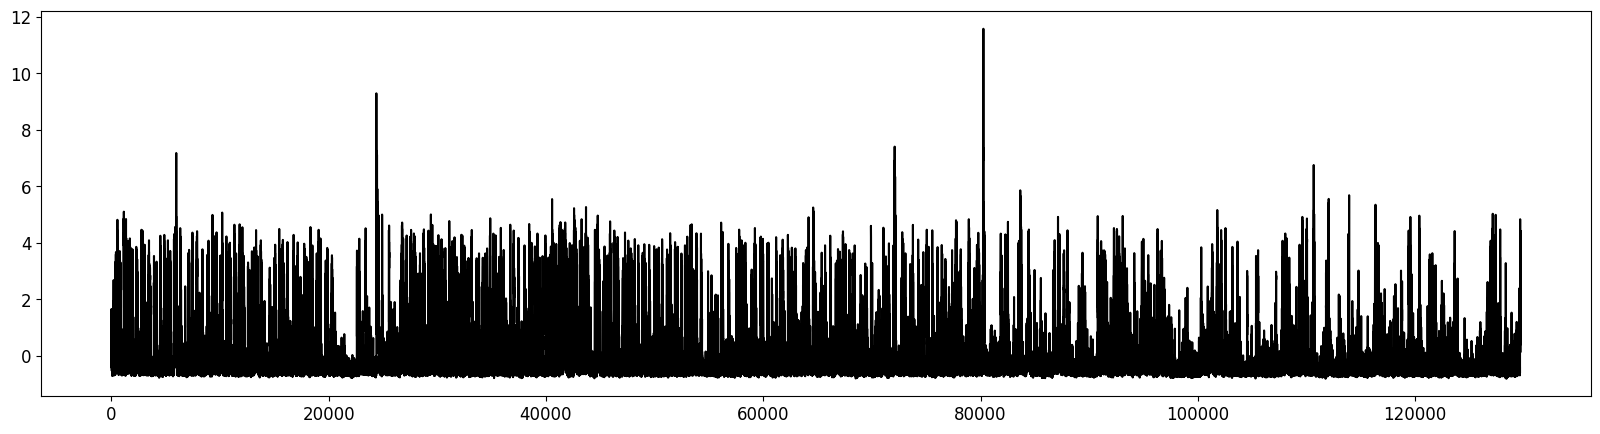

In [ ]:
mice = states_file[['mouse_name', 'session', 'broader_label']].drop_duplicates().sort_values(by='mouse_name')
sessions = mice['session'].unique()
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

for s, session in enumerate(sessions):
    # session = '4a45c8ba-db6f-4f11-9403-56e06a33dfa4'
    states = states_file.loc[states_file['session']==session]
    mouse_name = list(states['mouse_name'])[0]
    fit_id = str(mouse_name+session)
    trials_file = data_path + "session_trials_" + str(session) + '_'  + mouse_name
    session_trials = pd.read_parquet(trials_file, engine='pyarrow').reset_index() 

    identifiable_states = states["identifiable_states"] #.dropna()
    digits = identifiable_states.str.extract(r'(\d)(\d)(\d)(\d)').astype(int)
    digits.columns = ["paw", "whisk", "lick" , "wheel"] #
    states['paw'] = digits['paw']
    states['whisk'] = digits['whisk']
    states['lick'] = digits['lick']
    states['wheel'] = digits['wheel']
    states['epoch'] = pd.factorize(states['broader_label'])[0]

    # Plot raw trace over states       
    init = 1000
    inter = 1000
    wheel_over_wavelet_clusters(init, inter, states, session_trials, 'whisk')
    # wheel_over_wavelet_clusters(init, inter, states, session_trials, 'paw')

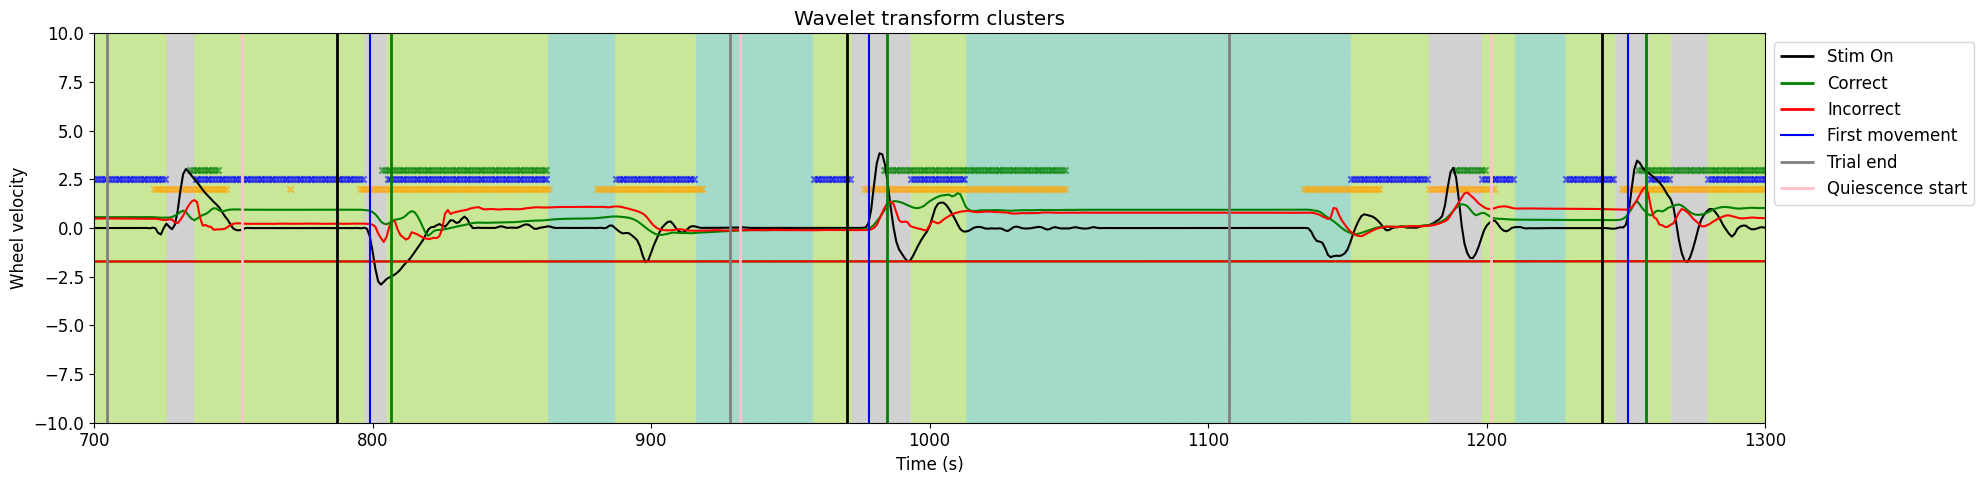

In [16]:
# Plot raw trace over states       
init = 700
inter = 600
wheel_over_wavelet_clusters(init, inter, states.reset_index(), session_trials, 'wheel')

# Wheel movements

In [13]:
sessions = states_file['session'].unique()
trial_movement = pd.DataFrame()
for s, session in enumerate(sessions):
    
    session_data = states_file.loc[states_file['session']==session]
    # TODO: need to multiply by frame rate to be in px/second
    wheel = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['avg_wheel_vel'].apply(lambda x: np.nanmean(x))).reset_index()
    l_paw_x = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['l_paw_x'].apply(lambda x: np.nanmean(np.abs(np.diff(x/2))))).reset_index()
    l_paw_y = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['l_paw_y'].apply(lambda x: np.nanmean(np.abs(np.diff(x/2))))).reset_index()
    r_paw_x = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['r_paw_x'].apply(lambda x: np.nanmean(np.abs(np.diff(x))))).reset_index()
    r_paw_y = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['r_paw_y'].apply(lambda x: np.nanmean(np.abs(np.diff(x))))).reset_index()
    
    trial_df = wheel.merge(l_paw_x, on=['session', 'trial_id', 'identifiable_states', 'broader_label'])
    trial_df = trial_df.merge(l_paw_y, on=['session', 'trial_id', 'identifiable_states', 'broader_label'])
    trial_df = trial_df.merge(r_paw_x, on=['session', 'trial_id', 'identifiable_states', 'broader_label'])
    trial_df = trial_df.merge(r_paw_y, on=['session', 'trial_id', 'identifiable_states', 'broader_label'])


    if s == 0:
        trial_movement = trial_df.copy()
    else:
        trial_movement = pd.concat((trial_movement, trial_df.copy()))

/tmp/ipykernel_44889/4172468685.py:8: RuntimeWarning: Mean of empty slice
  l_paw_x = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['l_paw_x'].apply(lambda x: np.nanmean(np.abs(np.diff(x/2))))).reset_index()
/tmp/ipykernel_44889/4172468685.py:9: RuntimeWarning: Mean of empty slice
  l_paw_y = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['l_paw_y'].apply(lambda x: np.nanmean(np.abs(np.diff(x/2))))).reset_index()
/tmp/ipykernel_44889/4172468685.py:10: RuntimeWarning: Mean of empty slice
  r_paw_x = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['r_paw_x'].apply(lambda x: np.nanmean(np.abs(np.diff(x))))).reset_index()
/tmp/ipykernel_44889/4172468685.py:11: RuntimeWarning: Mean of empty slice
  r_paw_y = pd.DataFrame(session_data.groupby(['session', 'trial_id', 'identifiable_states', 'broader_label'])['r_paw_y'].apply(lambda x: np.na

In [14]:
trial_movement['paw_states'] = trial_movement['identifiable_states'].str[:1]
trial_movement['whisk_states'] = trial_movement['identifiable_states'].str[1:2]
trial_movement['lick_states'] = trial_movement['identifiable_states'].str[2:3]
trial_movement['wheel_states'] = trial_movement['identifiable_states'].str[3:4]

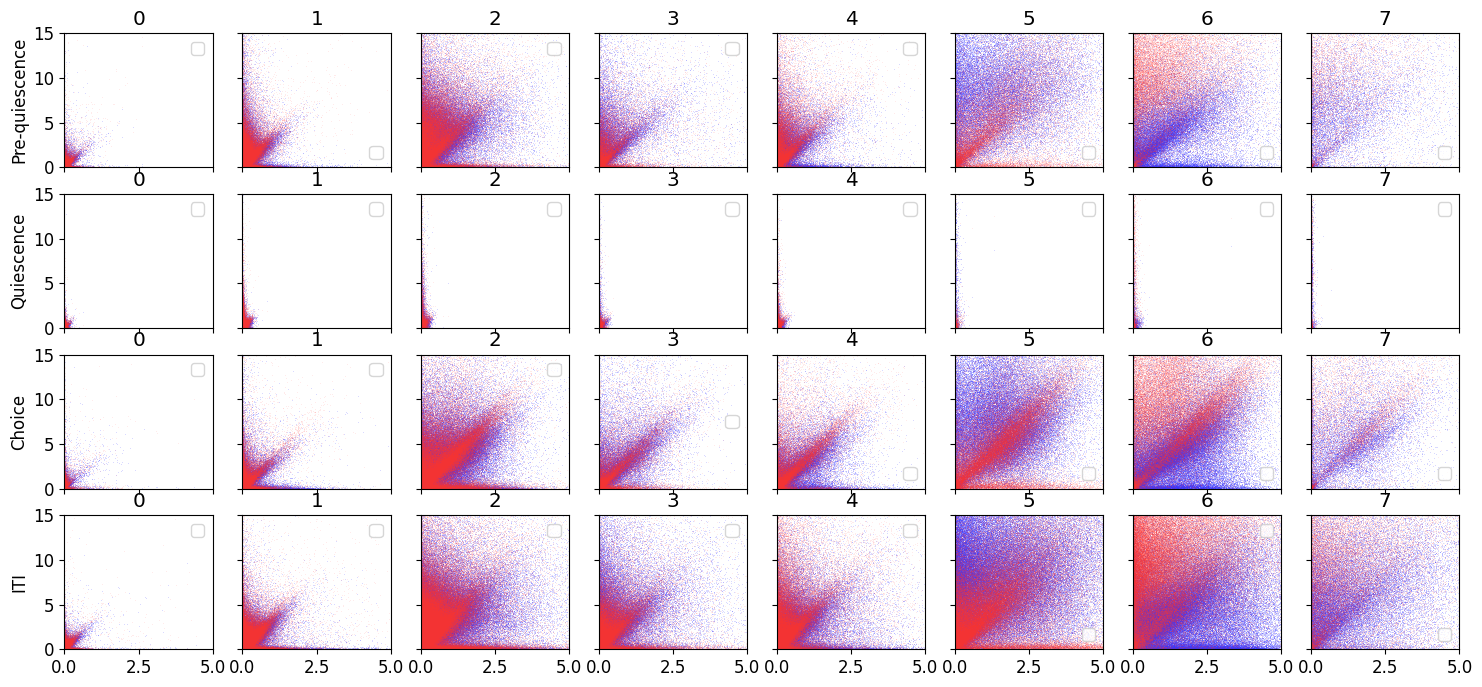

In [32]:
select_data = trial_movement.loc[trial_movement['session']=='88224abb-5746-431f-9c17-17d7ef806e6a']
select_data = trial_movement.copy()
paw_unique = np.unique(select_data['paw_states'])
paw_states = np.arange(0, len(paw_unique), 1)
epochs = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

fig, axs = plt.subplots(4, len(paw_unique), sharex=True, sharey=True, figsize=(18, 8))
for c, cluster in enumerate(paw_states):
    for i in range(4):
        use_data = select_data.loc[(select_data['paw_states']==str(cluster)) & 
                                         (select_data['broader_label']==epochs[i])].reset_index()
        use_data['avg_wheel_vel'] = np.abs(use_data['avg_wheel_vel'])
        sns.scatterplot(x=np.array(use_data['avg_wheel_vel']).astype(float), y=use_data['l_paw_x'].astype(float), 
                    marker='o', color='blue', s=.5, alpha=.2, ax=axs[i, c], label='left') 
        sns.scatterplot(x=np.array(use_data['avg_wheel_vel']).astype(float), y=use_data['r_paw_x'].astype(float), 
                    marker='o', color='red', s=.5, alpha=.1, ax=axs[i, c], label='right') 
        axs[i, c].set_title(cluster)
        axs[i, c].set_ylabel(epochs[i])
        axs[i, c].set_ylim([0, 15])
        axs[i, c].set_xlim([0, 5])
        axs[i, c].legend('')

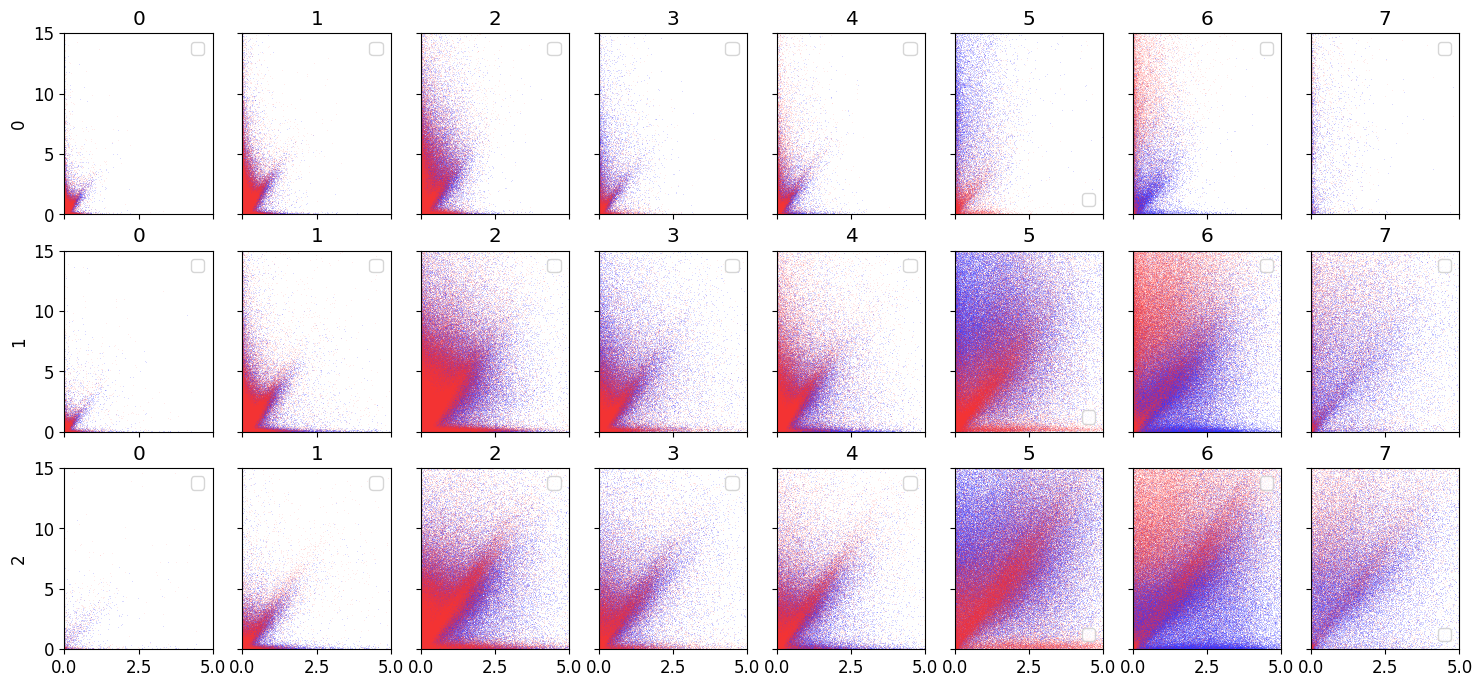

In [33]:
select_data = trial_movement.copy()
paw_unique = np.unique(select_data['paw_states'])
paw_states = np.arange(0, len(paw_unique), 1)

fig, axs = plt.subplots(3, len(paw_unique), sharex=True, sharey=True, figsize=(18, 8))
for c, cluster in enumerate(paw_states):
    for i, state in enumerate(['0', '1', '2']):
        use_data = select_data.loc[(select_data['paw_states']==str(cluster)) & 
                                         (select_data['wheel_states']==state)].reset_index()
        use_data['avg_wheel_vel'] = np.abs(use_data['avg_wheel_vel'])
        sns.scatterplot(x=np.array(use_data['avg_wheel_vel']).astype(float), y=use_data['l_paw_x'].astype(float), 
                    marker='o', color='blue', s=.5, alpha=.2, ax=axs[i, c], label='left') 
        sns.scatterplot(x=np.array(use_data['avg_wheel_vel']).astype(float), y=use_data['r_paw_x'].astype(float), 
                    marker='o', color='red', s=.5, alpha=.1, ax=axs[i, c], label='right') 
        axs[i, c].set_title(cluster)
        axs[i, c].set_ylabel(state)
        axs[i, c].set_ylim([0, 15])
        axs[i, c].set_xlim([0, 5])
        axs[i, c].legend('')